In [1]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from src.model_Twin import TwinFiLMUNetTiny
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.plot import(
    plot_csi_sorted_sequence_exact,
)
from torch.utils.data import DataLoader
from src.utils import crop_back, pad_to_32,merge_day_night_on_time

In [2]:
# load model

PATH = "Model_checkpoint/Swin+_elevation_no_twil_10mins_fuzzy.pth"
# torch.save(model.state_dict(), PATH)
device = torch.device("cuda:0" if torch.backends.mps.is_available() else "cpu")
import torch
import torch.nn.functional as F
from src.model_Twin import(TwinFiLMUNetTiny3L,TwinFiLMUNetTiny) 
# 1) load checkpoint
model = TwinFiLMUNetTiny(feature_size = 48)
model.load_state_dict(torch.load(PATH))
model.to(device)


TwinFiLMUNetTiny(
  (enc_atmos): Sequential(
    (0): Conv2d(9, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
    (3): ResBlockGN(
      (c1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n1): GroupNorm(8, 48, eps=1e-05, affine=True)
      (c2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n2): GroupNorm(8, 48, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
    )
  )
  (enc_geo): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
  )
  (film): FiLM(
    (gamma): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
    (beta): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
  )
  (down): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), paddi

In [13]:
# load normalization stats
norm_stats_path =  "Data/static/minmax_strat_stats_day_30mins_no_twillight_fuzzy.npz"
norm = np.load(norm_stats_path)
channel_min = norm['channel_min']
channel_max = norm['channel_max']
print("Loaded norm stats:", channel_min.shape, channel_max.shape)

Loaded norm stats: (12,) (12,)


In [17]:
#load night data with elevation and landmask
bands_npz_name = "Data/bands/modeldata/bands_night_paired_30mins_fuzzy_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"

In [18]:
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/combined_hourly_with_elev_landmask_fuzzy_night.npz",
)

KeyboardInterrupt: 

In [10]:
X_test, y_test = load_bands_and_cams(
    bands_npz_path="Data/output/combined_hourly_with_elev_landmask_fuzzy_night.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_night_paired_30mins_fuzzy_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (59236, 12, 50, 50)
y shape: (59236, 1, 50, 50)
X finite: True
y finite: True
X stats: min -54.519989013671875 max 804.1715698242188
y stats: min 0.0 max 1.0


In [14]:
night_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
night_loader  = DataLoader(night_dataset,  batch_size=64, shuffle=False)

In [33]:
y_pred = []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in night_loader:
        x_batch = x_batch.to(device)
        xb_pad, h, w = pad_to_32(x_batch)
        pred_y = model(xb_pad)
        pred_y = crop_back(pred_y, h, w).contiguous()
        y_pred.append(pred_y.cpu().numpy())
y_pred = np.concatenate(y_pred, axis=0)

out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy.npz"
night_t    = np.load(bands_npz_name)["time_min"]
np.savez_compressed(
    out_path,
    csi=y_pred,
    time_hourly=night_t,
)
print("Saved synthetic night CSI to", out_path)
print("y_pred night shape:", y_pred.shape)


Saved synthetic night CSI to Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy.npz
y_pred night shape: (59236, 1, 50, 50)


In [34]:
y_pred.shape

(59236, 1, 50, 50)

In [41]:
data= np.load("Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy.npz")
y_pred = data["csi"]
night_t = data["time_hourly"]


In [40]:
import numpy as np
out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy.npz"
# --- DAY truth CSI from CAMS (ghi_grid2500_2ch_day.npz) ---
cams_day_npz = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_fuzzy_no_twillight.npz", allow_pickle=True)
cams_day     = cams_day_npz["data"].astype(np.float32)   # (T_day, 2, 50, 50)
time_day     = cams_day_npz["time_min"]                      # (T_day,)
# load bands for time info only
night_t    = np.load(out_path)["time_hourly"]
eps = 1e-6
ghi_day    = cams_day[:, 0, :, :]  # (T_day, 50, 50)
ghi_cs_day = cams_day[:, 1, :, :]  # (T_day, 50, 50)

ghi_cs_safe = np.where(ghi_cs_day < eps, eps, ghi_cs_day)
csi_day = ghi_day / ghi_cs_safe                   # (T_day, 50, 50)
y_true_day = csi_day[:, None, :, :]               # (T_day, 1, 50, 50)
print("y_true_day:", y_true_day.shape)
print("y_pred_night:", night_t.shape)

y_true_day: (46277, 1, 50, 50)
y_pred_night: (59236,)


In [ ]:
csi_sorted, time_sorted, is_day_sorted = merge_day_night_on_time(
    y_true_day, time_day,
    y_pred, night_t
)
print("sorted time range:", time_sorted[0], "→", time_sorted[-1])
print("frames:", len(time_sorted), "day:", is_day_sorted.sum(), "night:", (~is_day_sorted).sum())

sorted time range: 2021-01-01 10:30:00 → 2023-12-31 23:40:00
frames: 105513 day: 46277 night: 59236


In [42]:
import numpy as np
import pandas as pd

def merge_day_night_on_time_hourly(
    y_true_day, time_day,
    y_pred_night, time_night,
    *,
    unit="m",      # same as before
    origin="unix",
):
    time_day   = np.asarray(time_day).astype(np.int64)
    time_night = np.asarray(time_night).astype(np.int64)

    # --- filter to hourly timestamps only (exact hour boundary) ---
    dt_day   = pd.to_datetime(time_day,   unit=unit, origin=origin)
    dt_night = pd.to_datetime(time_night, unit=unit, origin=origin)

    day_mask   = (dt_day.minute == 0) & (dt_day.second == 0) & (dt_day.microsecond == 0)
    night_mask = (dt_night.minute == 0) & (dt_night.second == 0) & (dt_night.microsecond == 0)

    time_day_h   = time_day[day_mask]
    y_true_day_h = y_true_day[day_mask]

    time_night_h   = time_night[night_mask]
    y_pred_night_h = y_pred_night[night_mask]

    # maps keep LAST occurrence (matches your original dict behavior)
    day_map   = {t: i for i, t in enumerate(time_day_h)}
    night_map = {t: i for i, t in enumerate(time_night_h)}

    all_times_raw = np.array(sorted(set(day_map) | set(night_map)), dtype=np.int64)

    C, H, W = y_true_day.shape[1:]
    T_total = len(all_times_raw)

    csi_sorted    = np.full((T_total, C, H, W), np.nan, dtype=np.float32)
    is_day_sorted = np.zeros(T_total, dtype=bool)

    for k, t in enumerate(all_times_raw):
        if t in day_map:  # day wins on duplicates
            csi_sorted[k] = y_true_day_h[day_map[t]]
            is_day_sorted[k] = True
        else:
            csi_sorted[k] = y_pred_night_h[night_map[t]]
            is_day_sorted[k] = False

    all_times = pd.to_datetime(all_times_raw, unit=unit, origin=origin)
    return csi_sorted, all_times, is_day_sorted


In [44]:
csi_h, hours, is_day_h = merge_day_night_on_time_hourly(
    y_true_day, time_day, y_pred, night_t
)

In [46]:
hours.shape

(26104,)

In [45]:
np.savez_compressed(
    "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy.npz",
    csi=csi_h,
    time_hourly=hours,
)

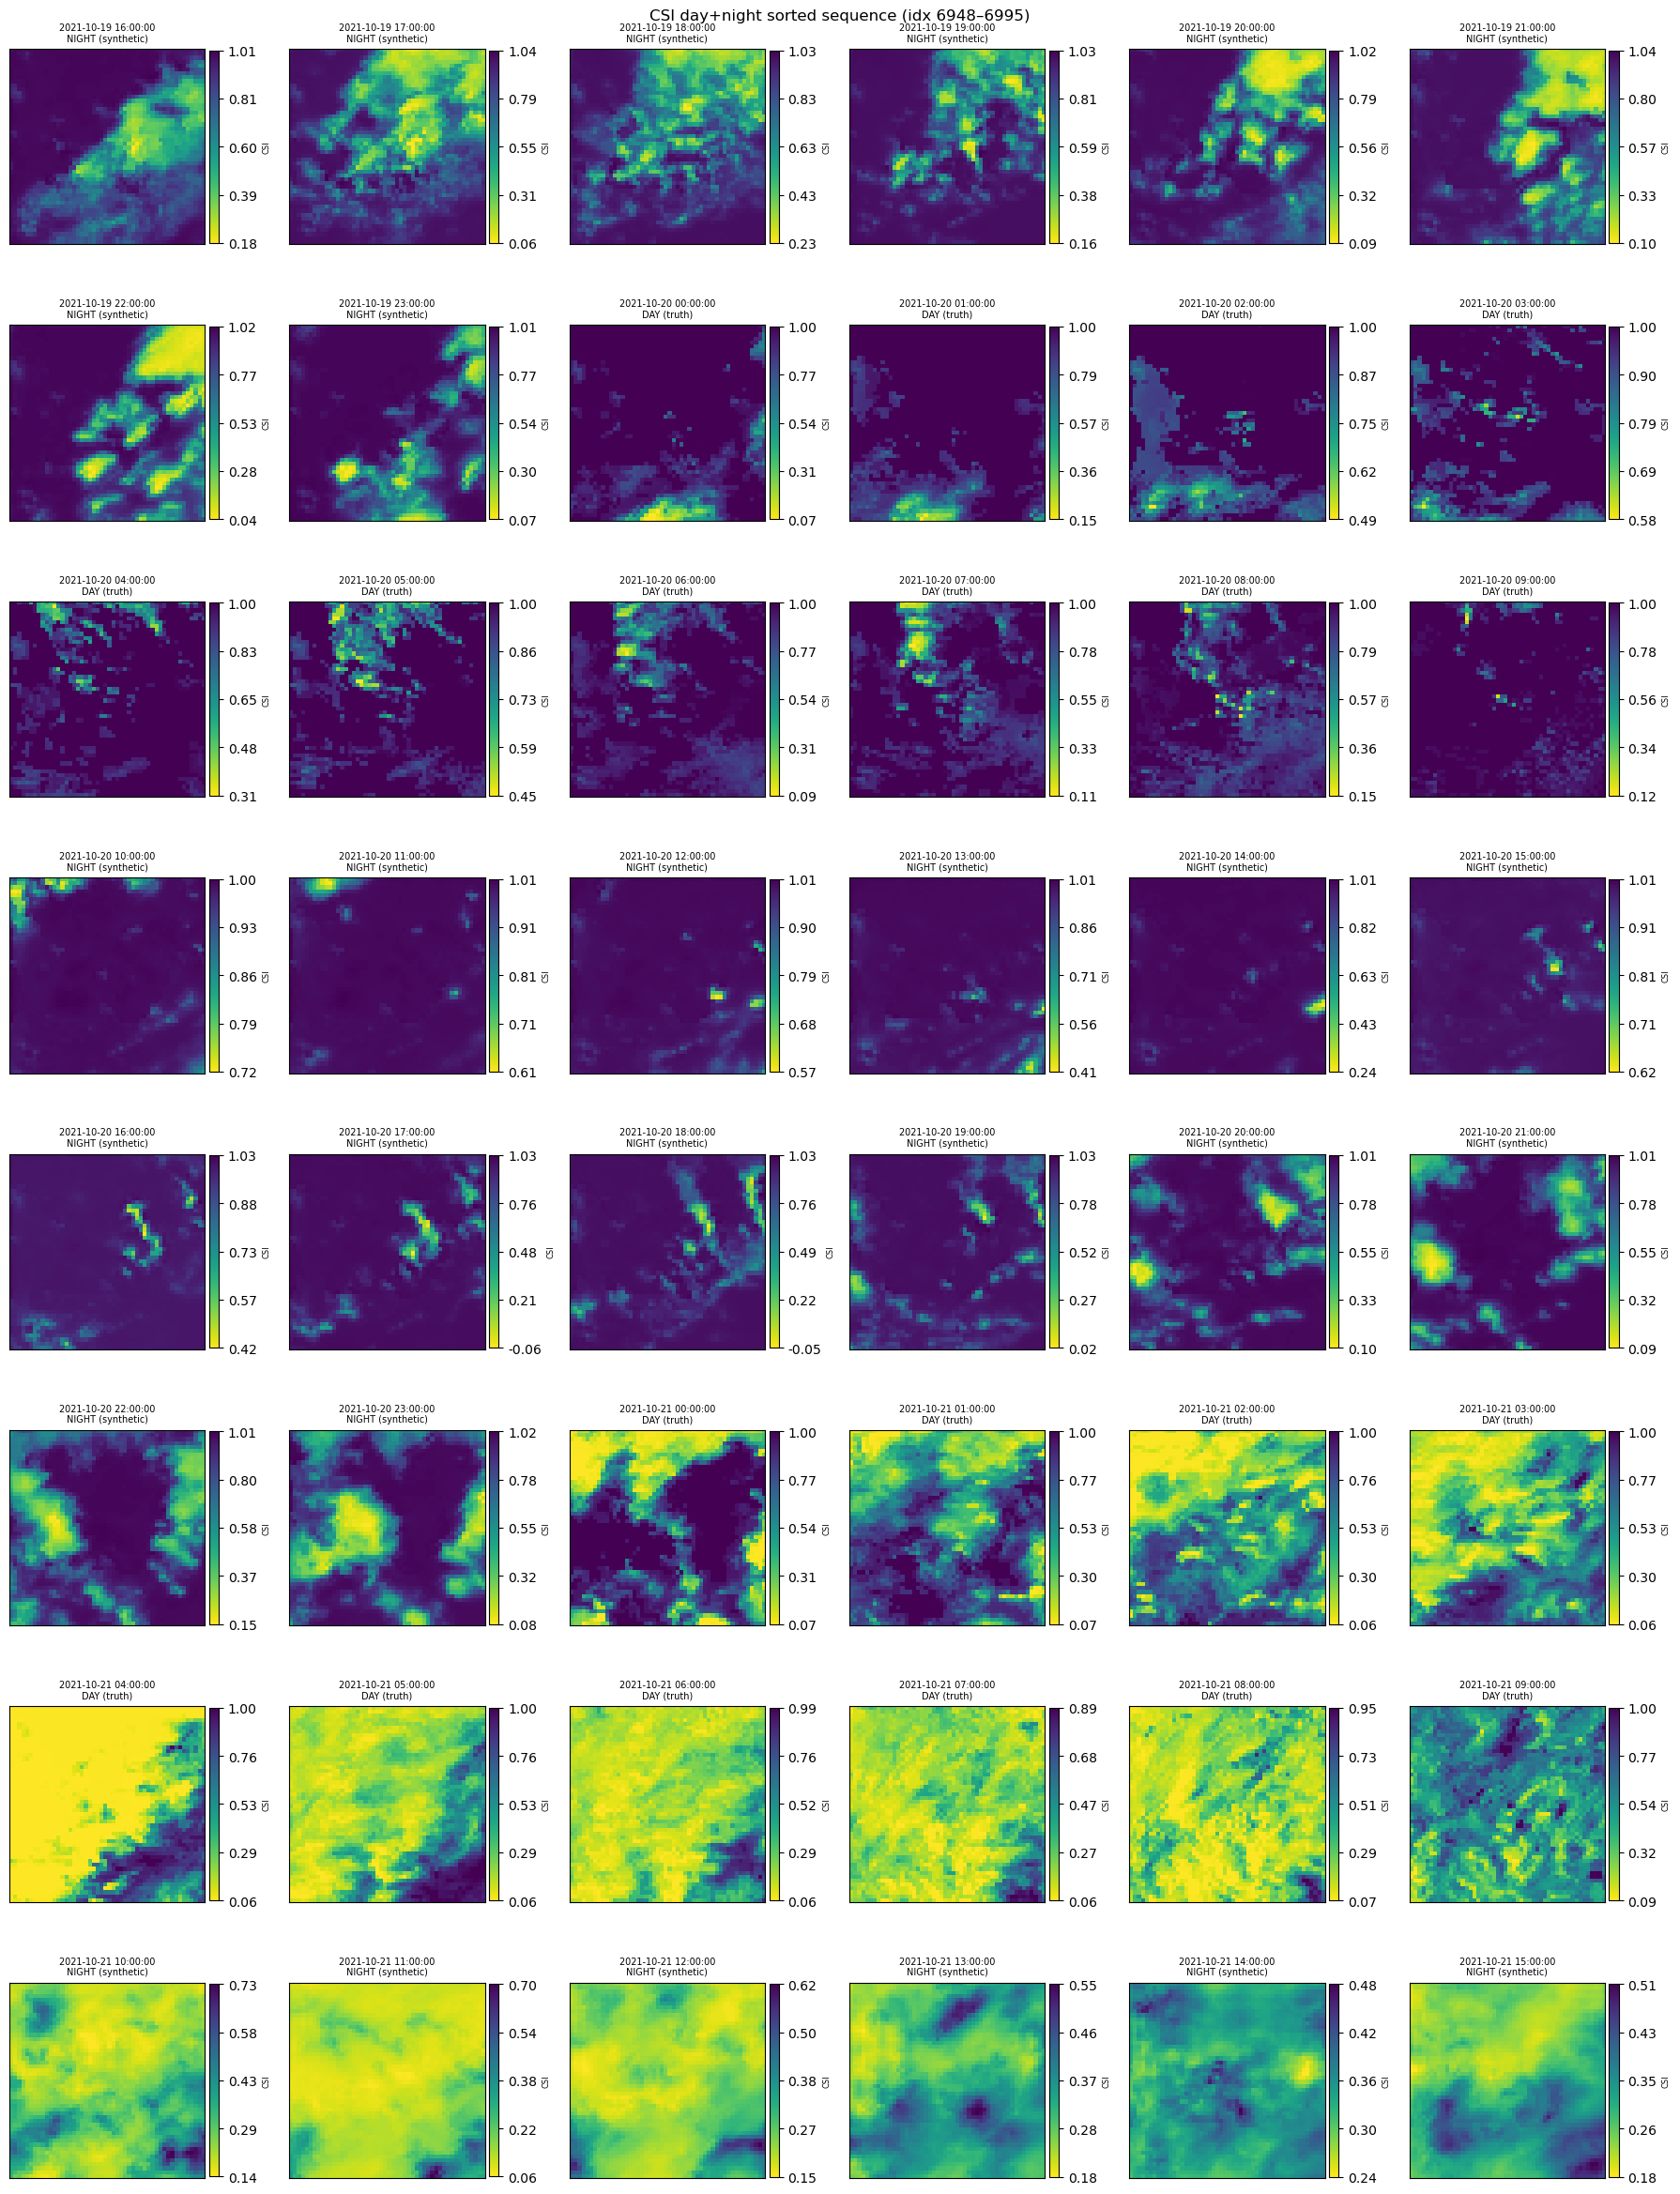

In [47]:
# first 24 hours in the whole period
plot_csi_sorted_sequence_exact(
    csi_h, hours, is_day_h,
    start_idx=6996-48, #1048+42
    num_steps=24*2,
    cols=6,
)

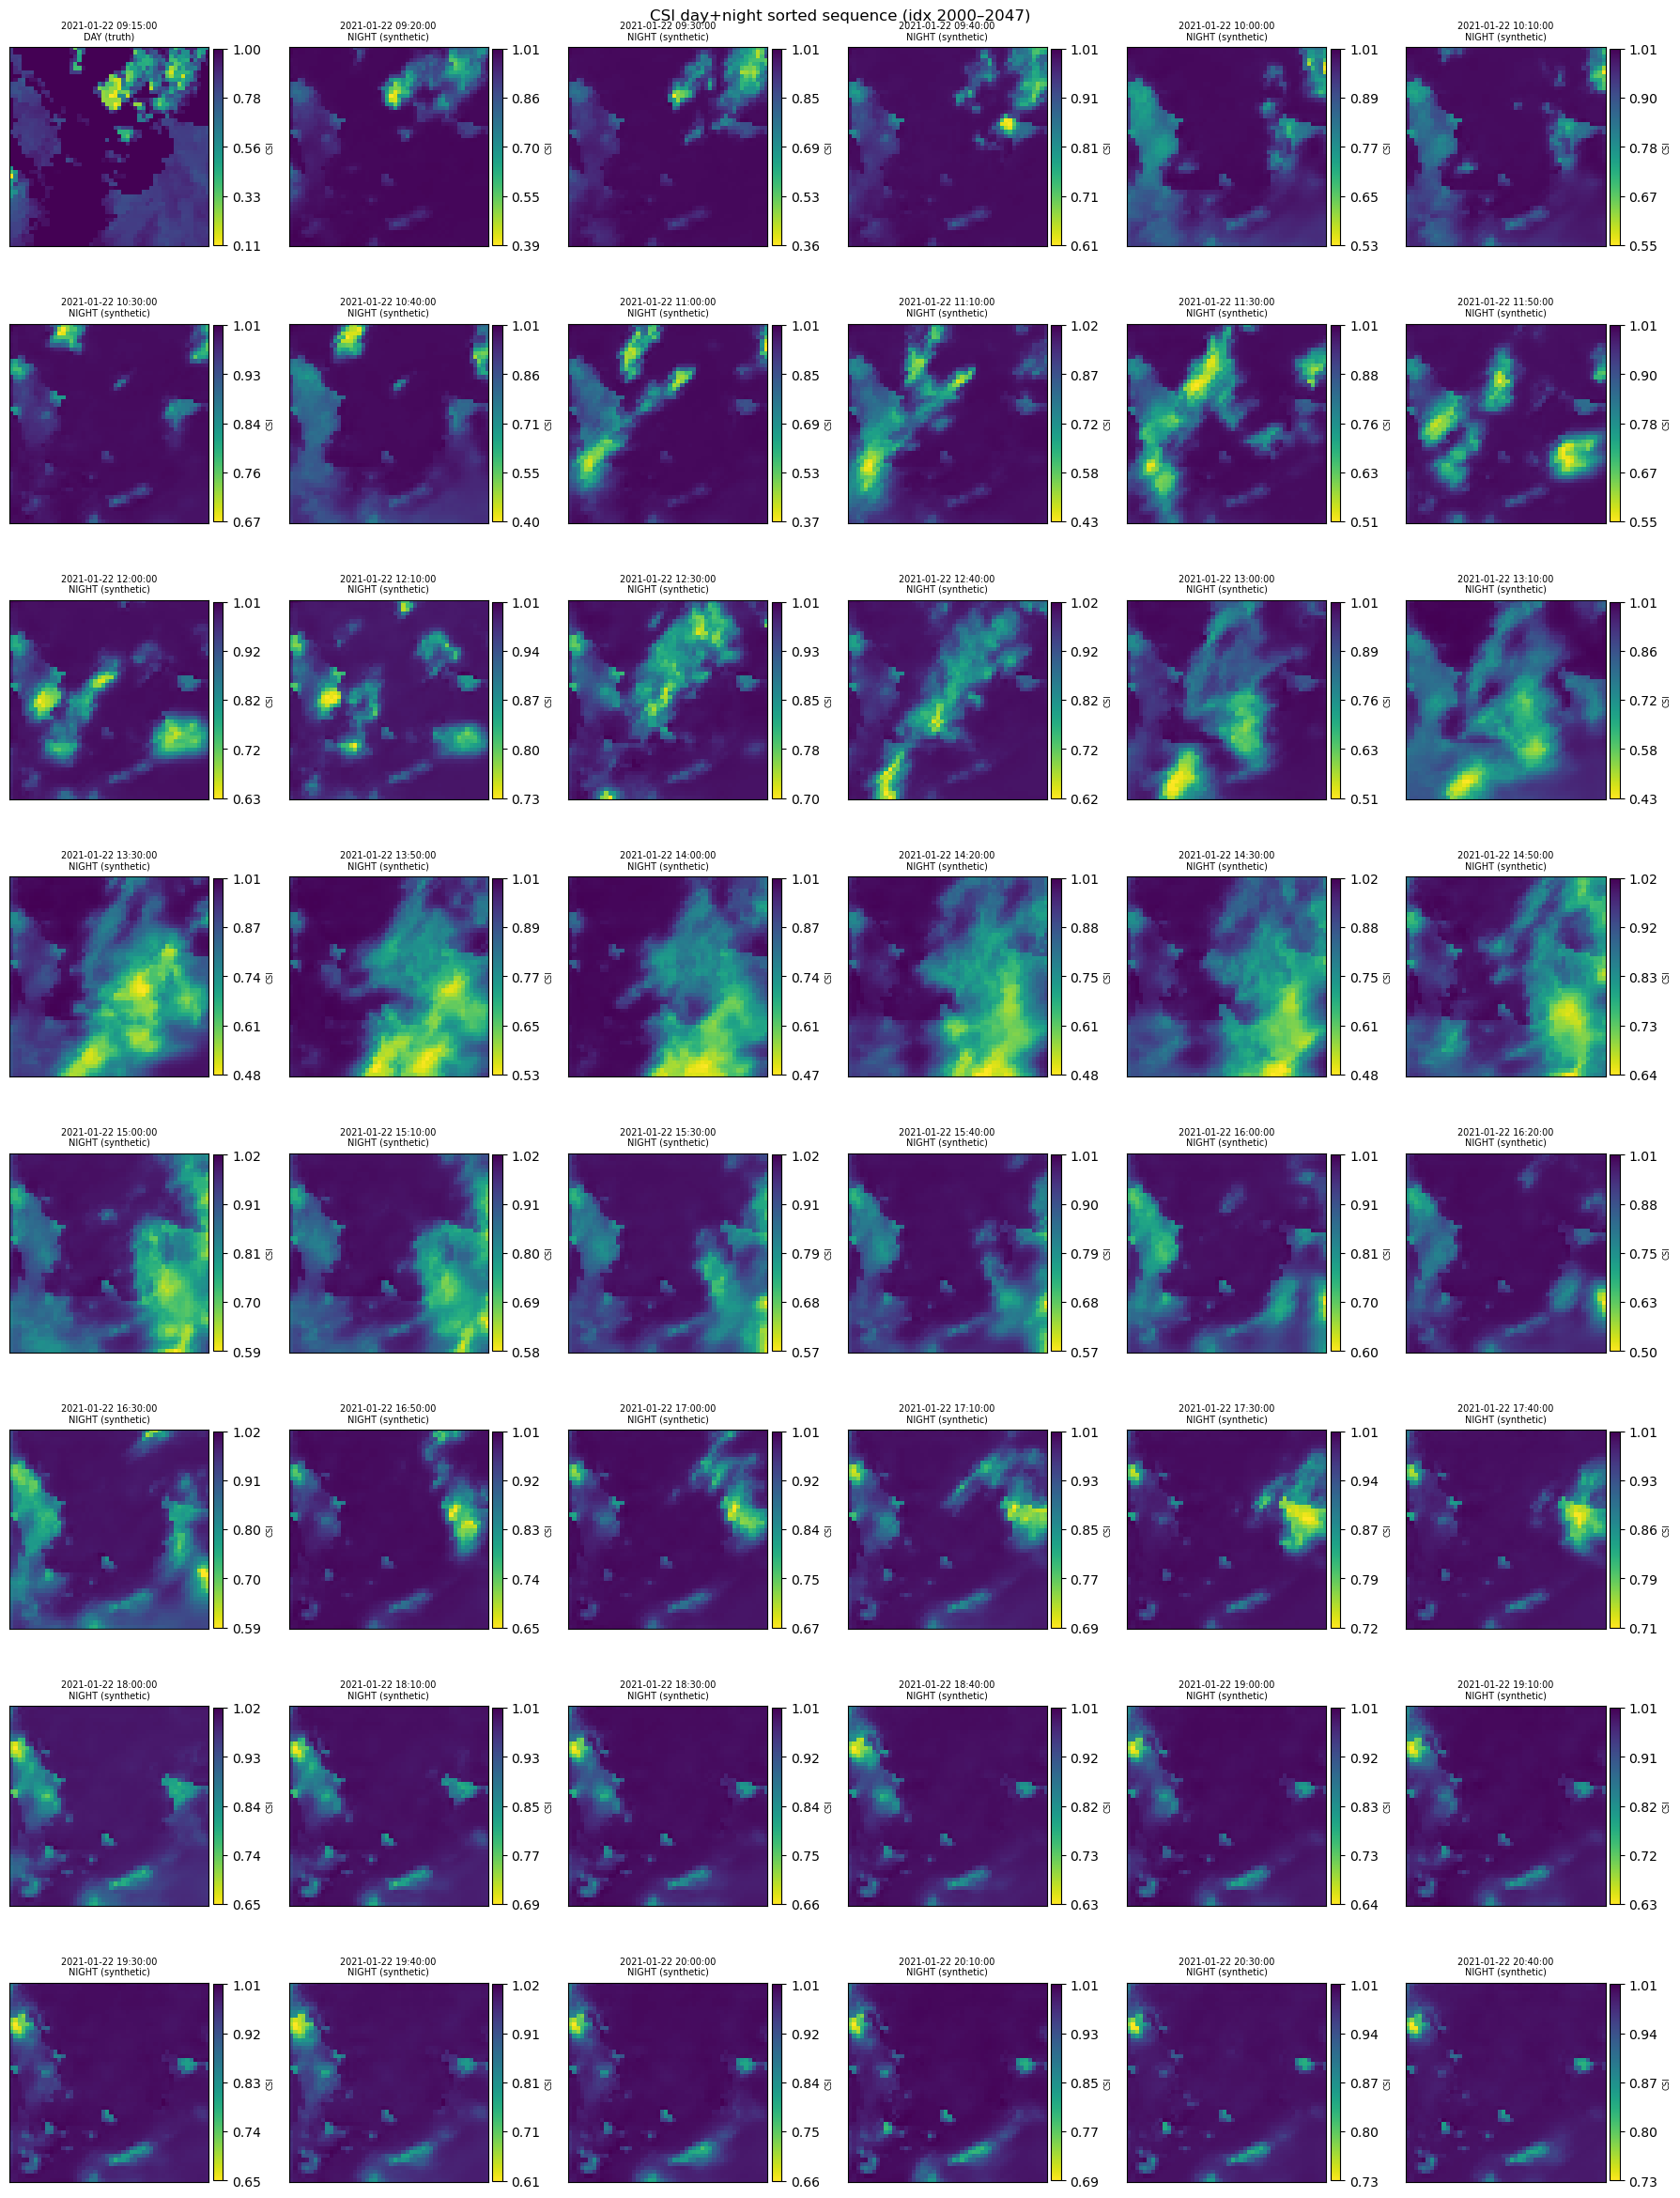

In [17]:
# first 24 hours in the whole period
plot_csi_sorted_sequence_exact(
    csi_sorted, time_sorted, is_day_sorted,
    start_idx=2000,
    num_steps=24*2,
    cols=6,
)